In [1]:
#! Imports, seed, locked paths and main-run provenance
import hashlib
import json
import os
import random
import sys
import time

from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from google.colab import drive
from IPython.display import display
from torchvision import models

drive.mount('/content/drive')
SEED = 6304
ROOT = Path('/content/drive/MyDrive/pa1-beyond-iid')
PACS_DIR = ROOT / 'data/pacs'
SHARED_DIR = ROOT / 'shared'
TASK2_DIR = ROOT / 'task2'
MODEL_DIR = TASK2_DIR / 'models'
METHOD_DIR = TASK2_DIR / 'methods'
CONFIG_DIR = TASK2_DIR / 'configs'
STUDY_DIR = TASK2_DIR / 'results/dan_strength'
STUDY_DIR.mkdir(parents=True, exist_ok=True)
BASE_PATH = CONFIG_DIR / 'base.json'
SPLIT_FILE = SHARED_DIR / 'splits/pacs_sketch_seed6304.json'
ERM_CONFIG_PATH = CONFIG_DIR / 'source_only.json'
MAIN_CONFIG_PATH = CONFIG_DIR / 'dan.json'
INITIAL_PATH = MODEL_DIR / 'resnet18_initial_seed6304.pt'
MAIN_BEST_PATH = MODEL_DIR / 'dan_best.pt'
MAIN_LAST_PATH = MODEL_DIR / 'dan_last.pt'
MAIN_RESULTS = TASK2_DIR / 'results/dan'
ADAPTATION_FILE = SHARED_DIR / 'pacs_adaptation.py'
DAN_FILE = METHOD_DIR / 'dan.py'

required = [BASE_PATH, SPLIT_FILE, ERM_CONFIG_PATH, INITIAL_PATH, MAIN_CONFIG_PATH,
            MAIN_BEST_PATH, MAIN_LAST_PATH, MAIN_RESULTS / 'history.csv',
            PACS_DIR / 'pacs_sources.tar', PACS_DIR / 'pacs_target_unlabeled.tar',
            PACS_DIR / 'source_train.csv', PACS_DIR / 'source_val.csv',
            PACS_DIR / 'target_unlabeled.csv', SHARED_DIR / 'pacs.py',
            SHARED_DIR / 'pacs_training.py', ADAPTATION_FILE, DAN_FILE]

missing = [str(p) for p in required if not p.is_file()]

if missing:
    raise FileNotFoundError('Complete and verify Task 2A, B and C first: ' + str(missing))

def sha256(path):
    digest = hashlib.sha256()

    with open(path, 'rb') as stream:
        for block in iter(lambda: stream.read(4 * 1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

base = json.loads(BASE_PATH.read_text())
split = json.loads(SPLIT_FILE.read_text())
erm_config = json.loads(ERM_CONFIG_PATH.read_text())
main_config = json.loads(MAIN_CONFIG_PATH.read_text())
main_last = torch.load(MAIN_LAST_PATH, map_location='cpu', weights_only=True)
main_best = torch.load(MAIN_BEST_PATH, map_location='cpu', weights_only=True)
initial = torch.load(INITIAL_PATH, map_location='cpu', weights_only=True)
SOURCE_DOMAINS = ['photo', 'art_painting', 'cartoon']
LABEL_NAMES = list(base['class_names'])
INITIAL_SHA = sha256(INITIAL_PATH)
MAIN_CONFIG_SHA = sha256(MAIN_CONFIG_PATH)

if (base['seed'] != SEED or split['seed'] != SEED
        or base['source_domains'] != SOURCE_DOMAINS or base['target_domain'] != 'sketch'
        or len(LABEL_NAMES) != 7 or initial['seed'] != SEED
        or initial['class_names'] != LABEL_NAMES
        or main_config['lambda_mmd'] != 1.0
        or not main_last['finished']
        or main_best['run_config_sha256'] != MAIN_CONFIG_SHA
        or main_last['run_config_sha256'] != MAIN_CONFIG_SHA
        or main_best['initial_checkpoint_sha256'] != INITIAL_SHA
        or erm_config['initial_checkpoint_sha256'] != INITIAL_SHA
        or main_config['initial_checkpoint_sha256'] != INITIAL_SHA
        or main_config['source_split_sha256'] != sha256(SPLIT_FILE)):
    raise RuntimeError('Locked protocol, completed main DAN, or initial weights do not agree')

PROTECTED_HASHES = {str(p): sha256(p) for p in
                    [INITIAL_PATH, MAIN_CONFIG_PATH, MAIN_BEST_PATH, MAIN_LAST_PATH,
                     ADAPTATION_FILE, DAN_FILE, BASE_PATH, SPLIT_FILE]}

BN_REFERENCE = {k: v.detach().cpu().clone() for k, v in initial['model_state_dict'].items()
                if k.endswith(('running_mean', 'running_var', 'num_batches_tracked'))}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device:', DEVICE, '| T4 recommended')
print('Completed λ=1 checkpoint:', MAIN_BEST_PATH, '| best epoch:', main_best['epoch'])
print('Prior models and source splits protected by hashes; target labels not accessed.')

Mounted at /content/drive
Device: cuda | T4 recommended
Completed λ=1 checkpoint: /content/drive/MyDrive/pa1-beyond-iid/task2/models/dan_best.pt | best epoch: 8
Prior models and source splits protected by hashes; target labels not accessed.


In [2]:
#! Load shared source/target data and unchanged DAN loss
sys.path.insert(0, str(SHARED_DIR))
sys.path.insert(0, str(METHOD_DIR))

from pacs import make_loaders, set_seed
from pacs_training import evaluate_sources, atomic_torch_save, cpu_state_dict
from pacs_adaptation import train_adaptation_epoch
from dan import dan_objective, multi_kernel_mmd2, KERNEL_MULTIPLIERS

source_loaders, val_loaders, target_loader = make_loaders(
    PACS_DIR, Path('/content/pacs_task2_adaptation'), include_target=True, workers=2
)

source_train = pd.read_csv(PACS_DIR / 'source_train.csv')
source_val = pd.read_csv(PACS_DIR / 'source_val.csv')

target_manifest = pd.read_csv(PACS_DIR / 'target_unlabeled.csv')

if set(source_train['hf_index']) & set(source_val['hf_index']):
    raise RuntimeError('Source train/validation image IDs overlap')

if {'label', 'label_name'} & set(target_manifest.columns):
    raise RuntimeError('Unlabeled Sketch manifest contains a class label')

if not target_loader.dataset.unlabeled:
    raise RuntimeError('Target loader must expose images only')

if tuple(KERNEL_MULTIPLIERS) != (0.5, 1.0, 2.0):
    raise RuntimeError('Unexpected DAN kernel multipliers')

STEPS_PER_EPOCH = max(len(source_loaders[d]) for d in SOURCE_DOMAINS)

if (STEPS_PER_EPOCH != main_config['steps_per_source_epoch']
        or STEPS_PER_EPOCH != erm_config['steps_per_source_epoch']
        or min(len(source_loaders[d]) for d in SOURCE_DOMAINS) == 0
        or len(target_loader) == 0):
    raise RuntimeError('Batching/epoch length changed relative to main DAN')

images_only = next(iter(target_loader))

if not isinstance(images_only, torch.Tensor) or len(images_only) != 24:
    raise RuntimeError('Target batch must contain exactly 24 images and no labels')

del images_only

print('Same train/validation splits, source epoch length:', STEPS_PER_EPOCH)
print('Training batch: source 8 + 8 + 8; target 24 unlabeled.')

Same train/validation splits, source epoch length: 234
Training batch: source 8 + 8 + 8; target 24 unlabeled.


In [3]:
#! Lock study design without reading target labels or modifying λ=1
LAMBDAS = (0.1, 1.0, 10.0)
TRAIN_LAMBDAS = (0.1, 10.0)

def tag_for(lam):
    return {0.1: '0p1', 1.0: '1', 10.0: '10'}[float(lam)]

def paths_for(lam):
    tag = tag_for(lam)
    return {
        'config': CONFIG_DIR / f'dan_lambda_{tag}.json',
        'best': MODEL_DIR / f'dan_lambda_{tag}_best.pt',
        'last': MODEL_DIR / f'dan_lambda_{tag}_last.pt',
        'result': STUDY_DIR / f'lambda_{tag}',
    }

STUDY_PATH = CONFIG_DIR / 'dan_strength_study.json'

study = {
    'study': 'Task 2 controlled DAN MMD strength', 'seed': SEED,
    'lambda_mmd_values': list(LAMBDAS), 'reused_main_lambda': 1.0,
    'main_config_sha256': MAIN_CONFIG_SHA,
    'main_best_checkpoint_sha256': PROTECTED_HASHES[str(MAIN_BEST_PATH)],
    'initial_checkpoint_sha256': INITIAL_SHA,
    'source_split_sha256': sha256(SPLIT_FILE),
    'method_sha256': sha256(DAN_FILE),
    'shared_training_loop_sha256': sha256(ADAPTATION_FILE),
    'qualitative_hypothesis_before_target_evaluation': (
        'Increasing MMD pressure may lower domain separability but can harm '
        'source class-discrimination when excessive; target accuracy is uncertain.'
    ),
    'evaluation_plan': ('Compare per-source validation accuracy/macro-F1 and the mean; '
                        'compute domain separability and labeled Sketch outcomes only '
                        'later in Task 2G after all settings and checkpoints are frozen.'),
    'source_only_selection_rule': ('Highest mean of source-validation macro-F1; '
                                   'ties resolved by smaller lambda. Main method remains lambda=1.'),
    'target_labels_used_to_choose_hyperparameters': False,
}

if STUDY_PATH.is_file():
    if json.loads(STUDY_PATH.read_text()) != study:
        raise RuntimeError('Existing controlled-study plan differs. Do not rewrite decisions post hoc.')
else:
    STUDY_PATH.write_text(json.dumps(study, indent=2))

STUDY_SHA = sha256(STUDY_PATH)

#! Derive each configuration from EXACT main DAN configuration; change λ and identifier only.
CONFIGS = {}

for lam in TRAIN_LAMBDAS:
    paths = paths_for(lam)
    paths['result'].mkdir(parents=True, exist_ok=True)
    cfg = dict(main_config)
    cfg['lambda_mmd'] = lam
    cfg['study_parent_config_sha256'] = MAIN_CONFIG_SHA
    cfg['study_plan_sha256'] = STUDY_SHA
    cfg['run_id'] = f'dan_strength_lambda_{tag_for(lam)}'

    if paths['config'].is_file():
        if json.loads(paths['config'].read_text()) != cfg:
            raise RuntimeError(f'Existing λ={lam} config differs. Do not overwrite prior experiment.')
    else:
        paths['config'].write_text(json.dumps(cfg, indent=2))

    CONFIGS[lam] = cfg

    print(f'λ={lam:g}: config={paths["config"].name}, checkpoint={paths["best"].name}')

print('Main λ=1 remains unchanged:', MAIN_BEST_PATH)

λ=0.1: config=dan_lambda_0p1.json, checkpoint=dan_lambda_0p1_best.pt
λ=10: config=dan_lambda_10.json, checkpoint=dan_lambda_10_best.pt
Main λ=1 remains unchanged: /content/drive/MyDrive/pa1-beyond-iid/task2/models/dan_best.pt


In [4]:
#! Reusable training function for λ=0.1 and λ=10; never touches λ=1 files

def new_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 7)
    model.load_state_dict(initial['model_state_dict'], strict=True)
    return model.to(DEVICE)


def snapshot_rng():
    return {
        'torch': torch.get_rng_state(),
        'cuda': torch.cuda.get_rng_state_all() if torch.cuda.is_available() else [],
        'python': random.getstate(),
        'numpy_name': np.random.get_state()[0],
        'numpy_keys': np.random.get_state()[1].tolist(),
        'numpy_position': int(np.random.get_state()[2]),
        'numpy_has_gauss': int(np.random.get_state()[3]),
        'numpy_cached_gaussian': float(np.random.get_state()[4]),
    }


def restore_rng(state):
    torch.set_rng_state(state['torch'])

    if torch.cuda.is_available() and state['cuda']:
        torch.cuda.set_rng_state_all(state['cuda'])

    random.setstate(state['python'])

    np.random.set_state((state['numpy_name'],
                         np.asarray(state['numpy_keys'], dtype=np.uint32),
                         state['numpy_position'], state['numpy_has_gauss'],
                         state['numpy_cached_gaussian']))


def train_strength(lam):
    paths = paths_for(lam)
    cfg = CONFIGS[lam]
    run_sha = sha256(paths['config'])
    set_seed(SEED)

    model = new_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['learning_rate'],
                                  weight_decay=cfg['weight_decay'])

    scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')

    history = []

    best_f1, best_epoch, bad_epochs, start_epoch = -1., 0, 0, 1

    finished = False

    if paths['last'].is_file():
        last = torch.load(paths['last'], map_location='cpu', weights_only=True)

        if (last['run_config_sha256'] != run_sha or last['lambda_mmd'] != lam
                or last['initial_checkpoint_sha256'] != INITIAL_SHA):
            raise RuntimeError(f'λ={lam} resume checkpoint has incompatible provenance')

        if not paths['best'].is_file():
            raise FileNotFoundError(f'λ={lam} best model is missing; investigate before resuming')

        model.load_state_dict(last['model_state_dict'], strict=True)
        optimizer.load_state_dict(last['optimizer_state_dict'])
        scaler.load_state_dict(last['scaler_state_dict'])

        history = last['history']

        best_f1, best_epoch, bad_epochs = last['best_f1'], last['best_epoch'], last['bad_epochs']

        start_epoch, finished = last['epoch'] + 1, last['finished']

        restore_rng(last['rng_state'])

        print(f'λ={lam:g}: resumed after epoch {last["epoch"]}; finished={finished}')
    elif paths['best'].exists():
        raise RuntimeError(f'λ={lam} best checkpoint exists without a resumable state')
    else:
        print(f'λ={lam:g}: fresh run from locked initial weights')

    #! Keep the same original DAN loss; only substitute the chosen coefficient.
    objective = partial(dan_objective, lambda_mmd=lam)

    if not finished:
        for epoch in range(start_epoch, cfg['max_epochs'] + 1):
            started = time.perf_counter()

            train = train_adaptation_epoch(
                model, source_loaders, target_loader, optimizer, DEVICE,
                epoch=epoch, objective=objective, scaler=scaler, seed=SEED
            )
            val = evaluate_sources(model, val_loaders, DEVICE, num_classes=7)

            score = val['mean_macro_f1']

            if score > best_f1 + 1e-8:
                best_f1, best_epoch, bad_epochs = score, epoch, 0

                atomic_torch_save({
                    'method': 'dan_mmd', 'study': 'alignment_strength',
                    'lambda_mmd': lam, 'seed': SEED, 'epoch': epoch,
                    'best_source_val_mean_macro_f1': best_f1,
                    'source_validation': val, 'run_config_sha256': run_sha,
                    'study_plan_sha256': STUDY_SHA,
                    'initial_checkpoint_sha256': INITIAL_SHA,
                    'class_names': LABEL_NAMES,
                    'model_state_dict': cpu_state_dict(model),
                }, paths['best'])
            else:
                bad_epochs += 1

            row = {
                'epoch': epoch, 'lambda_mmd': lam, **train,
                'mean_source_val_accuracy': val['mean_accuracy'],
                'mean_source_val_macro_f1': score,
                'worst_source_val_macro_f1': val['worst_source_macro_f1'],
                'elapsed_seconds': time.perf_counter() - started,
            }

            for domain in SOURCE_DOMAINS:
                row[f'val_{domain}_accuracy'] = val[domain]['accuracy']
                row[f'val_{domain}_macro_f1'] = val[domain]['macro_f1']
                row[f'val_{domain}_loss'] = val[domain]['loss']

            history.append(row)
            finished = bad_epochs >= cfg['patience'] or epoch == cfg['max_epochs']
            atomic_torch_save({
                'epoch': epoch, 'finished': finished,
                'lambda_mmd': lam, 'initial_checkpoint_sha256': INITIAL_SHA,
                'model_state_dict': cpu_state_dict(model),
                'optimizer_state_dict': optimizer.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
                'rng_state': snapshot_rng(),
                'history': history, 'best_epoch': best_epoch,
                'best_f1': best_f1, 'bad_epochs': bad_epochs,
                'run_config_sha256': run_sha,
            }, paths['last'])

            pd.DataFrame(history).to_csv(paths['result'] / 'history.csv', index=False)

            print(f'λ={lam:g} epoch {epoch:02d} | CE={row["train_cls_loss"]:.4f} '
                  f'| MMD²={row["train_alignment_loss"]:.4f} '
                  f'| val mean F1={score:.4f} | best={best_f1:.4f} '
                  f'(epoch {best_epoch}) | patience={bad_epochs}/5 '
                  f'| {row["elapsed_seconds"]:.0f}s')
            if finished:
                break

    if not finished:
        raise RuntimeError(f'λ={lam} training is unfinished; resume before final comparison')

    best = torch.load(paths['best'], map_location='cpu', weights_only=True)

    if (best['run_config_sha256'] != run_sha
            or best['initial_checkpoint_sha256'] != INITIAL_SHA
            or best['lambda_mmd'] != lam):
        raise RuntimeError(f'λ={lam} saved best checkpoint failed provenance check')

    print(f'λ={lam:g} COMPLETE; best source-validation F1={best["best_source_val_mean_macro_f1"]:.4f} '
          f'at epoch {best["epoch"]}.')

    del model, optimizer, scaler

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    return best['epoch']

#! Verify the lambda substitution numerically without training or accessing target labels.
s = torch.randn(8, 512)
t = s + 1.0

logits = torch.randn(8, 7)

y = torch.arange(8) % 7

low, components = dan_objective(s, logits, y, t, None, 0, 1, lambda_mmd=0.1)
high, _ = dan_objective(s, logits, y, t, None, 0, 1, lambda_mmd=10.0)

if not torch.allclose(high - low, 9.9 * components['alignment'], atol=1e-5):
    raise RuntimeError('Lambda-only controlled change failed synthetic test')

print('Synthetic test passed: same classification term and MMD, only λ changes.')

Synthetic test passed: same classification term and MMD, only λ changes.


In [5]:
#! DAN MMD λ=0.1, trained from shared initial checkpoint
low_best_epoch = train_strength(0.1)

λ=0.1: fresh run from locked initial weights
λ=0.1 epoch 01 | CE=0.4662 | MMD²=0.3363 | val mean F1=0.9114 | best=0.9114 (epoch 1) | patience=0/5 | 46s
λ=0.1 epoch 02 | CE=0.1890 | MMD²=0.2421 | val mean F1=0.9253 | best=0.9253 (epoch 2) | patience=0/5 | 45s
λ=0.1 epoch 03 | CE=0.1363 | MMD²=0.2268 | val mean F1=0.9343 | best=0.9343 (epoch 3) | patience=0/5 | 50s
λ=0.1 epoch 04 | CE=0.1058 | MMD²=0.2163 | val mean F1=0.9408 | best=0.9408 (epoch 4) | patience=0/5 | 49s
λ=0.1 epoch 05 | CE=0.0679 | MMD²=0.2071 | val mean F1=0.9188 | best=0.9408 (epoch 4) | patience=1/5 | 50s
λ=0.1 epoch 06 | CE=0.0668 | MMD²=0.2064 | val mean F1=0.9234 | best=0.9408 (epoch 4) | patience=2/5 | 50s
λ=0.1 epoch 07 | CE=0.0906 | MMD²=0.2117 | val mean F1=0.9269 | best=0.9408 (epoch 4) | patience=3/5 | 49s
λ=0.1 epoch 08 | CE=0.0454 | MMD²=0.1984 | val mean F1=0.9149 | best=0.9408 (epoch 4) | patience=4/5 | 49s
λ=0.1 epoch 09 | CE=0.0412 | MMD²=0.1957 | val mean F1=0.9443 | best=0.9443 (epoch 9) | patience=0/

In [6]:
#! DAN MMD λ=10, independent checkpoint and resumable history
high_best_epoch = train_strength(10.0)

λ=10: fresh run from locked initial weights
λ=10 epoch 01 | CE=1.9488 | MMD²=0.2350 | val mean F1=0.0507 | best=0.0507 (epoch 1) | patience=0/5 | 50s
λ=10 epoch 02 | CE=1.9410 | MMD²=0.2079 | val mean F1=0.0507 | best=0.0507 (epoch 1) | patience=1/5 | 46s
λ=10 epoch 03 | CE=1.9382 | MMD²=0.2012 | val mean F1=0.0507 | best=0.0507 (epoch 1) | patience=2/5 | 48s
λ=10 epoch 04 | CE=2.0160 | MMD²=0.2196 | val mean F1=0.0507 | best=0.0507 (epoch 1) | patience=3/5 | 48s
λ=10 epoch 05 | CE=1.9348 | MMD²=0.1940 | val mean F1=0.0507 | best=0.0507 (epoch 1) | patience=4/5 | 48s
λ=10 epoch 06 | CE=1.9344 | MMD²=0.1285 | val mean F1=0.0507 | best=0.0507 (epoch 1) | patience=5/5 | 47s
λ=10 COMPLETE; best source-validation F1=0.0507 at epoch 1.


In [7]:
#! Source-side comparison and frozen BatchNorm audit; no target evaluation
rows, audits, checkpoint_manifest = [], [], {}

for lam in LAMBDAS:
    paths = paths_for(lam)

    if lam == 1.0:
        best_path = MAIN_BEST_PATH
        best = torch.load(best_path, map_location='cpu', weights_only=True)
        expected_sha = MAIN_CONFIG_SHA
    else:
        best_path = paths['best']

        if not paths['last'].is_file():
            raise RuntimeError(f'λ={lam:g} training has not finished')

        last = torch.load(paths['last'], map_location='cpu', weights_only=True)

        if not last['finished']:
            raise RuntimeError(f'λ={lam:g} training has not finished')

        best = torch.load(best_path, map_location='cpu', weights_only=True)
        expected_sha = sha256(paths['config'])

    if best['run_config_sha256'] != expected_sha or best['initial_checkpoint_sha256'] != INITIAL_SHA:
        raise RuntimeError(f'λ={lam:g} best checkpoint failed provenance verification')

    set_seed(SEED)

    evaluated_model = new_model()
    evaluated_model.load_state_dict(best['model_state_dict'], strict=True)

    validation = evaluate_sources(evaluated_model, val_loaders, DEVICE, num_classes=7)

    if not np.isclose(validation['mean_macro_f1'], best['best_source_val_mean_macro_f1'], atol=1e-8):
        raise RuntimeError(f'λ={lam:g} checkpoint does not reproduce source-selection score')

    for domain in SOURCE_DOMAINS:
        rows.append({'lambda_mmd': lam, 'domain': domain, **validation[domain],
                     'selected_epoch': best['epoch']})

    rows.append({'lambda_mmd': lam, 'domain': 'mean',
                 'accuracy': validation['mean_accuracy'],
                 'macro_f1': validation['mean_macro_f1'],
                 'loss': np.nan, 'n_images': np.nan,
                 'selected_epoch': best['epoch']})

    rows.append({'lambda_mmd': lam, 'domain': 'worst',
                 'accuracy': validation['worst_source_accuracy'],
                 'macro_f1': validation['worst_source_macro_f1'],
                 'loss': np.nan, 'n_images': np.nan,
                 'selected_epoch': best['epoch']})

    current = evaluated_model.state_dict()

    mismatch = [name for name, value in BN_REFERENCE.items()
                if not torch.equal(current[name].detach().cpu(), value)]

    if mismatch:
        raise RuntimeError(f'λ={lam:g} pretrained BatchNorm buffers changed: {mismatch[:5]}')

    affine_ok = all(m.weight.requires_grad and m.bias.requires_grad for m in evaluated_model.modules()
                    if isinstance(m, nn.modules.batchnorm._BatchNorm))

    if not affine_ok:
        raise RuntimeError(f'λ={lam:g} BatchNorm scale/bias unexpectedly frozen')

    audits.append({'lambda_mmd': lam, 'checked_buffers': len(BN_REFERENCE),
                   'stats_equal_to_pretrained': True, 'bn_affine_trainable': True})

    checkpoint_manifest[tag_for(lam)] = {
        'lambda_mmd': lam, 'best_path': str(best_path),
        'best_sha256': sha256(best_path), 'best_epoch': best['epoch'],
        'config_path': str(MAIN_CONFIG_PATH if lam == 1.0 else paths['config']),
        'source_mean_macro_f1': validation['mean_macro_f1'],
    }

    del evaluated_model

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

source_table = pd.DataFrame(rows)
source_table.to_csv(STUDY_DIR / 'source_validation_all_lambdas.csv', index=False)

(STUDY_DIR / 'batchnorm_audit.json').write_text(json.dumps(audits, indent=2))
(STUDY_DIR / 'checkpoint_manifest.json').write_text(json.dumps(checkpoint_manifest, indent=2))

print('Source-validation results (target labels not used):')

display(source_table[['lambda_mmd','domain','accuracy','macro_f1','selected_epoch']].round(4))

Source-validation results (target labels not used):


,lambda_mmd,domain,accuracy,macro_f1,selected_epoch
0,0.1,photo,0.9701,0.9673,9
1,0.1,art_painting,0.8976,0.8990,9
2,0.1,cartoon,0.9616,0.9666,9
3,0.1,mean,0.9431,0.9443,9
4,0.1,worst,0.8976,0.8990,9
5,1.0,photo,0.9820,0.9791,8
6,1.0,art_painting,0.9220,0.9243,8
7,1.0,cartoon,0.9552,0.9581,8
8,1.0,mean,0.9531,0.9538,8
9,1.0,worst,0.9220,0.9243,8


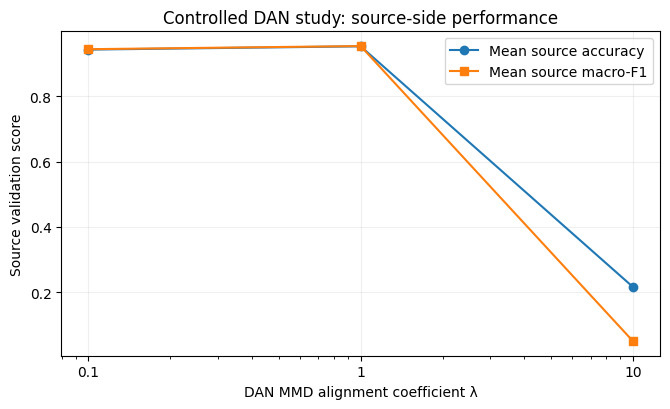

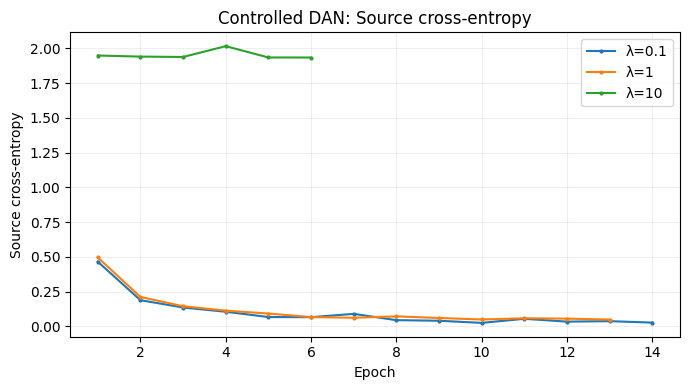

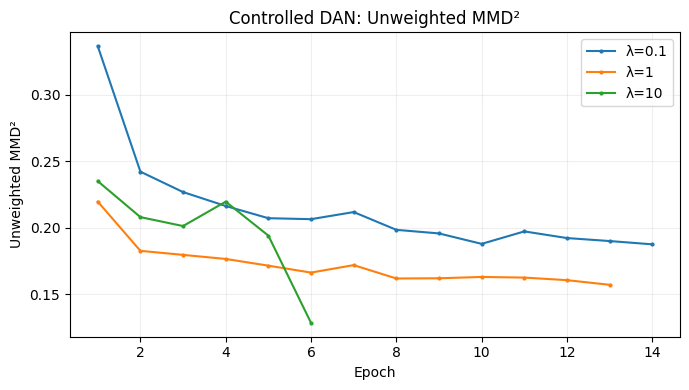

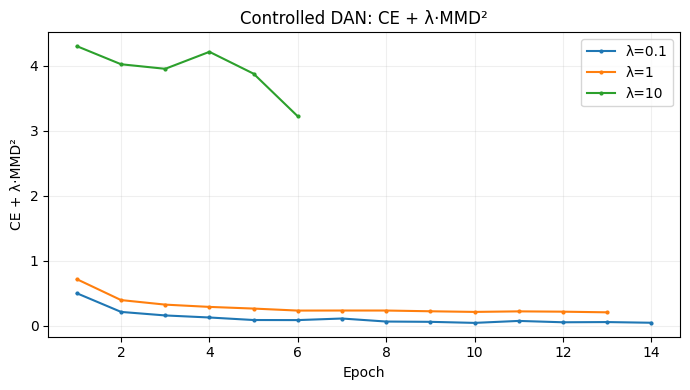

Permitted source-only diagnostic selection: {'criterion': 'Highest mean of source-validation macro-F1; ties resolved by smaller lambda. Main method remains lambda=1.', 'lambda_selected_without_target_labels': 1.0, 'source_validation_mean_macro_f1': 0.9538461470650068, 'main_comparison_lambda_unchanged': 1.0, 'target_labels_used': False}
No target metrics computed. Main comparison remains λ=1.


In [9]:
#! Study evidence and source-only selection; main λ=1 remains the main comparison

mean_rows = source_table[source_table['domain'] == 'mean'].sort_values('lambda_mmd')
source_choice = mean_rows.sort_values(['macro_f1', 'lambda_mmd'],
                                      ascending=[False, True]).iloc[0]

choice = {'criterion': study['source_only_selection_rule'],
          'lambda_selected_without_target_labels': float(source_choice['lambda_mmd']),
          'source_validation_mean_macro_f1': float(source_choice['macro_f1']),
          'main_comparison_lambda_unchanged': 1.0,
          'target_labels_used': False}

(STUDY_DIR / 'source_only_selection.json').write_text(json.dumps(choice, indent=2))

fig, ax = plt.subplots(figsize=(6.8, 4.2))

ax.plot(mean_rows['lambda_mmd'], mean_rows['accuracy'], marker='o', label='Mean source accuracy')
ax.plot(mean_rows['lambda_mmd'], mean_rows['macro_f1'], marker='s', label='Mean source macro-F1')

ax.set_xscale('log')
ax.set_xticks(LAMBDAS, labels=['0.1', '1', '10'])
ax.set(xlabel='DAN MMD alignment coefficient λ', ylabel='Source validation score',
       title='Controlled DAN study: source-side performance')
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()
fig.savefig(STUDY_DIR / 'source_performance_by_lambda.png', dpi=220)

plt.show()

histories = {}

for lam in LAMBDAS:
    history_path = MAIN_RESULTS / 'history.csv' if lam == 1.0 else paths_for(lam)['result'] / 'history.csv'

    if not history_path.is_file():
        raise FileNotFoundError('Missing training history: ' + str(history_path))

    histories[lam] = pd.read_csv(history_path)

    if not {'epoch', 'train_cls_loss', 'train_alignment_loss', 'train_total_loss'} <= set(histories[lam].columns):
        raise RuntimeError('Training history is missing loss components: ' + str(history_path))

for metric, output, label in [
    ('train_cls_loss', 'classification_loss_by_lambda.png', 'Source cross-entropy'),
    ('train_alignment_loss', 'mmd2_by_lambda.png', 'Unweighted MMD²'),
    ('train_total_loss', 'weighted_total_loss_by_lambda.png', 'CE + λ·MMD²')
]:
    fig, ax = plt.subplots(figsize=(7, 4))

    for lam in LAMBDAS:
        df = histories[lam]
        ax.plot(df['epoch'], df[metric], marker='o', markersize=2, label=f'λ={lam:g}')

    ax.set(xlabel='Epoch', ylabel=label, title='Controlled DAN: ' + label)
    ax.grid(alpha=0.2)
    ax.legend()

    fig.tight_layout()
    fig.savefig(STUDY_DIR / output, dpi=220)

    plt.show()

print('Permitted source-only diagnostic selection:', choice)
print('No target metrics computed. Main comparison remains λ=1.')

In [10]:
#! Final verification; preserve all earlier PACS experiments and defer target labels
required_study = [STUDY_PATH, STUDY_DIR / 'source_validation_all_lambdas.csv',
                  STUDY_DIR / 'batchnorm_audit.json', STUDY_DIR / 'checkpoint_manifest.json',
                  STUDY_DIR / 'source_only_selection.json',
                  STUDY_DIR / 'source_performance_by_lambda.png',
                  STUDY_DIR / 'classification_loss_by_lambda.png',
                  STUDY_DIR / 'mmd2_by_lambda.png',
                  STUDY_DIR / 'weighted_total_loss_by_lambda.png']

for lam in TRAIN_LAMBDAS:
    p = paths_for(lam)
    required_study.extend([p['config'], p['best'], p['last'], p['result'] / 'history.csv'])

missing = [str(p) for p in required_study if not p.is_file() or p.stat().st_size == 0]

if missing:
    raise FileNotFoundError('Incomplete controlled study: ' + str(missing))

for path, expected in PROTECTED_HASHES.items():
    if sha256(Path(path)) != expected:
        raise RuntimeError('Prior method or checkpoint was overwritten: ' + path)

for lam in TRAIN_LAMBDAS:
    p = paths_for(lam)

    last = torch.load(p['last'], map_location='cpu', weights_only=True)
    best = torch.load(p['best'], map_location='cpu', weights_only=True)

    history = pd.read_csv(p['result'] / 'history.csv')

    if (not last['finished'] or len(history) != last['epoch']
            or best['epoch'] != last['best_epoch']
            or best['run_config_sha256'] != sha256(p['config'])
            or best['study_plan_sha256'] != STUDY_SHA):
        raise RuntimeError(f'λ={lam:g} checkpoint/history verification failed')

if set(pd.read_csv(STUDY_DIR / 'source_validation_all_lambdas.csv')['lambda_mmd']) != set(LAMBDAS):
    raise RuntimeError('Missing at least one λ setting in the source results')

print('TASK 2F SOURCE-SIDE STUDY COMPLETE')
print('Verified files:', len(required_study), '| protected shared/main files:', len(PROTECTED_HASHES))
print('Both new DAN configurations finished; original λ=1 preserved.')
print('Next: Task 2G — domain-separability, final labeled Sketch evaluation and class analysis.')

TASK 2F SOURCE-SIDE STUDY COMPLETE
Verified files: 17 | protected shared/main files: 8
Both new DAN configurations finished; original λ=1 preserved.
Next: Task 2G — domain-separability, final labeled Sketch evaluation and class analysis.
